# 07 — Customer Alert Episodes and Blinded Pilot

Commercial users work customers, not repeated historical rows. This notebook converts monthly
flags into alert episodes, compares S2 and hurdle queues at fixed capacity, and prepares a blinded
250-case review sample spanning agreement, disagreement, peer-definition sensitivity, and
background cases.

The private allocation key records inclusion probabilities. Raw detector membership is withheld
from the blinded review file.

**Notebook structure:** the overlap charts compare the lenses at equal capacity. The pilot
chart documents the evaluation design. Business outcomes will be available after commercial
reviewers assess the cases.


In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

ROOT = Path('..').resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd

from module24_workflow import run_operational_layer

# Convert repeated monthly flags into customer-level review episodes.
metrics, episodes, blinded = run_operational_layer()
display(pd.DataFrame(metrics['capacity_overlap']).round(4))
display(pd.DataFrame(metrics['episode_counts']))
display(pd.DataFrame([metrics['repeat_customer_months_avoided']]))
display(
    pd.Series(metrics['pilot_strata'], name='cases')
    .rename_axis('sampling_stratum')
    .to_frame()
)
print(f"Blinded pilot rows: {metrics['pilot_rows']}.")


,capacity_per_month,channel_vs_hurdle_jaccard,channel_rows,hurdle_rows,overlap_rows
0,100,0.0850,600,600,94
1,250,0.0858,1500,1500,237
2,500,0.1272,3000,3000,677


,lens,episode_status,episodes
0,hurdle_cadence,new,1332
1,hurdle_cadence,ongoing,79
2,s2_channel,new,1265
3,s2_channel,ongoing,97


,hurdle_cadence,s2_channel
0,89,138


,cases
sampling_stratum,
channel_only,60
hurdle_only,60
background,50
agreement_core,40
peer_definition_disagreement,40


Blinded pilot rows: 250.


## Visual diagnostics

The plots show lens overlap at each review capacity, the composition of the blinded pilot, and how
many alert episodes are new versus continuing.


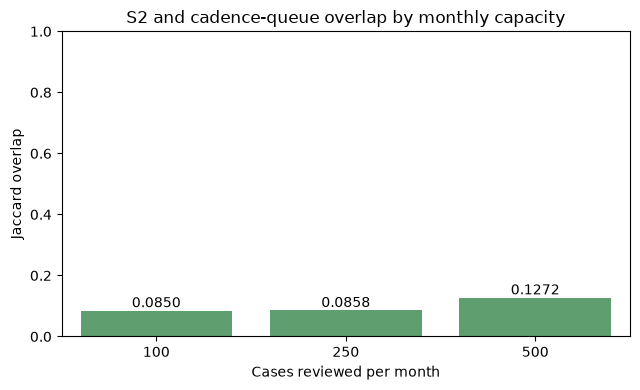

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

overlap = pd.DataFrame(metrics['capacity_overlap'])
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(
    data=overlap,
    x='capacity_per_month',
    y='channel_vs_hurdle_jaccard',
    ax=ax,
    color='#55A868',
)
ax.set_title('S2 and cadence-queue overlap by monthly capacity')
ax.set_xlabel('Cases reviewed per month')
ax.set_ylabel('Jaccard overlap')
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')
plt.tight_layout()
plt.show()


**Interpretation.** S2 and cadence overlap remains low at every tested review
capacity, so the two lenses contribute substantially different cases. Low overlap establishes
complementarity. Commercial precision requires reviewer outcomes.


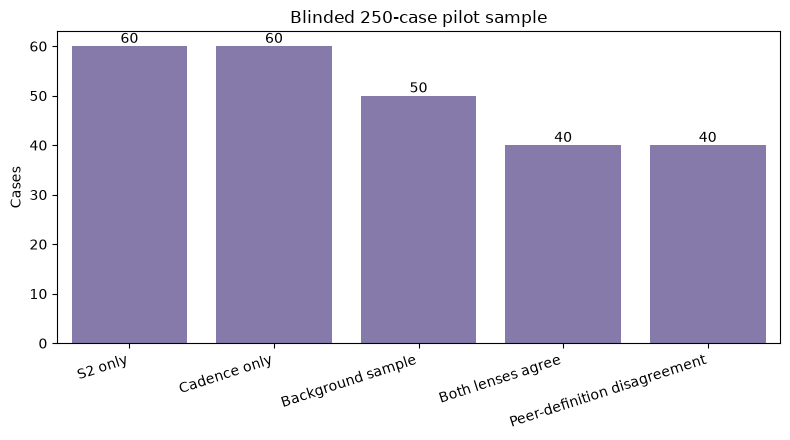

In [3]:
stratum_labels = {
    'channel_only': 'S2 only',
    'hurdle_only': 'Cadence only',
    'background': 'Background sample',
    'agreement_core': 'Both lenses agree',
    'peer_definition_disagreement': 'Peer-definition disagreement',
    'deterministic_fill': 'Deterministic capacity fill',
}
strata = (
    pd.Series(metrics['pilot_strata'], name='Cases')
    .rename_axis('sampling_stratum')
    .reset_index()
)
strata['Review stratum'] = strata['sampling_stratum'].map(stratum_labels)
strata = strata.sort_values('Cases', ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=strata, x='Review stratum', y='Cases', ax=ax, color='#8172B2')
ax.set_title('Blinded 250-case pilot sample')
ax.set_xlabel('')
ax.set_ylabel('Cases')
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
plt.show()


**Interpretation.** The pilot deliberately includes agreement,
single-lens, peer-sensitive, and background cases. These counts reflect the evaluation design,
not the natural prevalence of those groups, so raw stratum response rates must not be read as
deployed-queue precision.


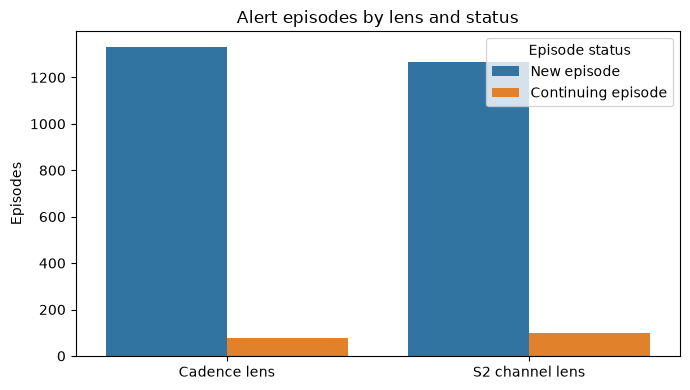

In [4]:
lens_labels = {
    'hurdle_cadence': 'Cadence lens',
    's2_channel': 'S2 channel lens',
}
status_labels = {'new': 'New episode', 'ongoing': 'Continuing episode'}
episode_counts = pd.DataFrame(metrics['episode_counts']).assign(
    **{
        'Lens': lambda frame: frame['lens'].map(lens_labels),
        'Episode status': lambda frame: frame['episode_status'].map(status_labels),
    }
)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=episode_counts,
    x='Lens',
    y='episodes',
    hue='Episode status',
    ax=ax,
)
ax.set_title('Alert episodes by lens and status')
ax.set_xlabel('')
ax.set_ylabel('Episodes')
plt.tight_layout()
plt.show()


**Interpretation.** Collapsing repeated monthly flags separates newly opened
review work from continuing customer episodes. This avoids counting the same continuing concern
as a fresh case each month and makes reviewer workload more representative of actual follow-up.


In [5]:
episode_duration = (
    episodes.assign(
        **{
            'Lens': episodes['lens'].map(lens_labels),
            'Episode status': episodes['episode_status'].map(status_labels),
        }
    )
    .groupby(['Lens', 'Episode status'])['months_flagged']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'Episodes', 'mean': 'Mean months flagged'})
    .round(2)
)
display(episode_duration)


Episodes  Mean months flagged
Lens            Episode status                                   
Cadence lens    Continuing episode        79                 2.13
                New episode             1332                 1.00
S2 channel lens Continuing episode        97                 2.42
                New episode             1265                 1.00

## Validation scope and operating gate

Technical evaluation measures forward prediction quality, queue overlap, peer-definition
sensitivity, and customer-clustered uncertainty. Statistical extremeness, agreement between
signals, and temporal stability are diagnostics for prioritization. Commercial relevance and
actionability are evaluated in the blinded review.

The operating gate is the blinded 250-case review. It measures usefulness, novelty,
actionability, review effort, and operating fit under the documented sampling design.


## Review outcomes

The canonical outcomes are `actionable_new`, `relevant_already_known`,
`real_but_not_actionable`, `false_or_unhelpful`, and `insufficient_context`. Precision at
capacity must be estimated from completed reviews using inclusion weights and reviewer-clustered
uncertainty. Before review completion, the file documents the evaluation design; business-value
evidence will be derived from the completed outcomes.
